In [75]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

In [76]:
def load_dataset():
    """
    Load the Iris dataset from a CSV file.

    Returns:
        tuple: A tuple containing:
            - X (np.ndarray): The feature matrix of shape (4, n_samples).
            - y (np.ndarray): The label vector of shape (n_samples,).
    """
    path = '../lab_2/iris.csv'  # Path to the CSV file
    data = []  # Initialize an empty list to store the data
    with open(path, 'r') as f:  # Open the file in read mode
        for line in f:  # Iterate over each line in the file
            data.append(line.strip().split(','))  # Split the line by commas and append to the data list
    mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}  # Mapping of class labels to integers
    X, y = [], []  # Initialize empty lists for features and labels
    for d in data:  # Iterate over each data entry
        X.append(list(map(float, d[:4])))  # Convert the first four elements to float and append to X
        y.append(mapping[d[4]])  # Map the class label to an integer and append to y
    return np.array(X).T, np.array(y)  # Return the feature matrix and label vector as numpy arrays

X, y = load_dataset()  # Load the dataset
print(X, y)  # Print the feature matrix and label vector

[[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
  5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
  5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5.  7.  6.4 6.9 5.5
  6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8 6.2 5.6 5.9 6.1
  6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.  6.7 6.3 5.6 5.5
  5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3 6.5 7.6 4.9 7.3
  6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6 7.7 6.3 6.7 7.2
  6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9 6.7 6.9 5.8 6.8
  6.7 6.7 6.3 6.5 6.2 5.9]
 [3.5 3.  3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 3.7 3.4 3.  3.  4.  4.4 3.9 3.5
  3.8 3.8 3.4 3.7 3.6 3.3 3.4 3.  3.4 3.5 3.4 3.2 3.1 3.4 4.1 4.2 3.1 3.2
  3.5 3.6 3.  3.4 3.5 2.3 3.2 3.5 3.8 3.  3.8 3.2 3.7 3.3 3.2 3.2 3.1 2.3
  2.8 2.8 3.3 2.4 2.9 2.7 2.  3.  2.2 2.9 2.9 3.1 3.  2.7 2.2 2.5 3.2 2.8
  2.5 2.8 2.9 3.  2.8 3.  2.9 2.6 2.4 2.4 2.7 2.7 3.  3.4 3.1 2.3 3.  2.5
  2.6 3.  2.

In [77]:
def dataset_mean(X):
    """
    Calculate the mean of the dataset.

    Args:
        X (np.ndarray): The feature matrix of shape (4, n_samples).

    Returns:
        np.ndarray: The mean vector of shape (4,).
    """
    return X.mean(1)  # Calculate and return the mean of each feature

mu = dataset_mean(X)  # Calculate the mean of the dataset
print(mu)  # Print the mean vector

[5.84333333 3.05733333 3.758      1.19933333]


In [78]:
def center_dataset(X):
    """
    Center the dataset by subtracting the mean.

    Args:
        X (np.ndarray): The feature matrix of shape (4, n_samples).

    Returns:
        np.ndarray: The centered feature matrix of shape (4, n_samples).
    """
    return X - X.mean(1).reshape(-1, 1)  # Subtract the mean from each feature and return the centered matrix

Xc = center_dataset(X)  # Center the dataset

In [79]:
def dataset_covariance_class_matrix(Xc, y):
    """
    Compute the covariance matrices for each class in the dataset.

    Args:
        Xc (np.ndarray): The centered feature matrix of shape (4, n_samples).
        y (np.ndarray): The label vector of shape (n_samples,).

    Returns:
        dict: A dictionary mapping each unique label (int) to its covariance matrix (np.ndarray of shape (4, 4)).
    """
    covs = {}  # Initialize an empty dictionary to store covariance matrices
    for l in np.unique(y):  # Iterate over each unique class label
        # Calculate the covariance matrix for the current class and store it in the dictionary
        covs[l] = (Xc[:, y == l] @ Xc[:, y == l].T) / float(Xc[:, y == l].shape[1])
    return covs  # Return the dictionary of covariance matrices

# Example usage assuming that Xc and y are already defined
cov = dataset_covariance_class_matrix(Xc, y)  # Compute the covariance matrices for each class
print(cov)  # Print the covariance matrices

{np.int64(0): array([[ 0.82289111, -0.21313956,  1.93854533,  0.80838178],
       [-0.21313956,  0.27820978, -0.83958667, -0.34425689],
       [ 1.93854533, -0.83958667,  5.301172  ,  2.19480133],
       [ 0.80838178, -0.34425689,  2.19480133,  0.91972844]]), np.int64(1): array([[ 0.26969111,  0.05685378,  0.22575867,  0.06640178],
       [ 0.05685378,  0.17906044, -0.06324133,  0.00398444],
       [ 0.22575867, -0.06324133,  0.468404  ,  0.13522667],
       [ 0.06640178,  0.00398444,  0.13522667,  0.05436844]]), np.int64(2): array([[ 0.95078444,  0.02983244,  1.633156  ,  0.66370311],
       [ 0.02983244,  0.10886844, -0.079548  , -0.02221289],
       [ 1.633156  , -0.079548  ,  3.516932  ,  1.530888  ],
       [ 0.66370311, -0.02221289,  1.530888  ,  0.75730178]])}


In [80]:
def dataset_covariance_within_class_matrix(Xc, y):
    """
    Compute the within-class covariance matrix for the dataset.

    Args:
        Xc (ndarray): Centered feature matrix of shape (features, n_samples).
        y (ndarray): Label vector of shape (n_samples,).

    Returns:
        ndarray: The within-class covariance matrix of shape (features, features).
    """
    covs = dataset_covariance_class_matrix(Xc, y)  # Compute the covariance matrices for each class
    acc = 0  # Initialize the accumulator for the within-class covariance matrix
    for l in np.unique(y):  # Iterate over each unique class label
        n_samples = Xc[:, y == l].shape[1]  # Get the number of samples in the current class
        acc += covs[l] * n_samples  # Update the accumulator with the weighted covariance matrix
    return acc / float(Xc.shape[1])  # Return the normalized within-class covariance matrix

cov_within = dataset_covariance_within_class_matrix(Xc, y)  # Compute the within-class covariance matrix
print(cov_within)  # Print the within-class covariance matrix

[[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


In [81]:
def dataset_covariance_between_class_matrix(X, y):
    """
    Compute the between-class covariance matrix for the dataset.

    Args:
        X (ndarray): Original feature matrix of shape (features, n_samples).
        y (ndarray): Label vector of shape (n_samples,).

    Returns:
        ndarray: Between-class covariance matrix of shape (features, features).
    """
    N = X.shape[1]  # Number of samples
    mu = dataset_mean(X)  # Overall mean vector
    acc = 0  # Accumulator for the covariance matrix
    for l in np.unique(y):  # Iterate over each unique class label
        X_class = X[:, y == l]  # Extract samples of the current class
        Nc = X_class.shape[1]  # Number of samples in the current class
        mu_c = X_class.mean(axis=1)  # Mean vector of the current class
        acc += Nc * np.outer(mu_c - mu, mu_c - mu)  # Update the accumulator with the outer product
    return acc / N  # Return the normalized between-class covariance matrix

# Compute and print the between-class covariance matrix
cov_between = dataset_covariance_between_class_matrix(X, y)  # Compute the between-class covariance matrix
print(cov_between)  # Print the between-class covariance matrix

[[ 0.42141422 -0.13301778  1.101656    0.47519556]
 [-0.13301778  0.07563289 -0.38159733 -0.15288444]
 [ 1.101656   -0.38159733  2.91401867  1.24516   ]
 [ 0.47519556 -0.15288444  1.24516     0.53608889]]


In [82]:
def dataset_covariance_within_class_matrix(X, y):
    """
    Compute the within-class covariance matrix for the dataset.

    Args:
        X (ndarray): Original feature matrix of shape (features, n_samples).
        y (ndarray): Label vector of shape (n_samples,).

    Returns:
        ndarray: The within-class covariance matrix of shape (features, features).
    """
    acc = 0  # Initialize the accumulator for the covariance matrix
    for l in np.unique(y):  # Iterate over each unique class label
        X_class = X[:, y == l]  # Extract samples of the current class
        # Center the class data by subtracting the class mean
        Xc_class = X_class - X_class.mean(axis=1).reshape(-1, 1)
        # Update the accumulator with the covariance of the current class
        acc += Xc_class @ Xc_class.T
    # Return the normalized within-class covariance matrix
    return acc / float(X.shape[1])

# Compute and print the within-class covariance matrix
cov_within = dataset_covariance_within_class_matrix(Xc, y)  # Compute the within-class covariance matrix
print(cov_within)  # Print the within-class covariance matrix

[[0.259708   0.09086667 0.164164   0.03763333]
 [0.09086667 0.11308    0.05413867 0.032056  ]
 [0.164164   0.05413867 0.181484   0.041812  ]
 [0.03763333 0.032056   0.041812   0.041044  ]]


In [83]:
def generalized_eigenvalue_resolver(Sb, Sw):
    """
    Compute the generalized eigenvalues and eigenvectors of the given matrices.

    Args:
        Sb (np.ndarray): Between-class covariance matrix of shape (4, 4).
        Sw (np.ndarray): Within-class covariance matrix of shape (4, 4).

    Returns:
        tuple: A tuple containing:
            - np.ndarray: Generalized eigenvalues of shape (4,).
            - np.ndarray: Generalized eigenvectors of shape (4, 4).
    """
    # Compute the generalized eigenvalues and eigenvectors
    s, U = scipy.linalg.eigh(Sb, Sw)
    return s, U

# Compute the generalized eigenvalues and eigenvectors
s, U = generalized_eigenvalue_resolver(cov_between, cov_within)
print(s)  # Print the eigenvalues
print(U)  # Print the eigenvectors

[-1.10026722e-14  2.34881654e-15  2.85391043e-01  3.21919292e+01]
[[ 2.14949563 -2.39624402  0.02434685  0.83779794]
 [-2.67032123  0.45860943  2.18649663  1.55005187]
 [-3.02536742  0.32826504 -0.94138258 -2.22355955]
 [ 4.36007012  1.49239477  2.86801283 -2.83899363]]


In [84]:
m = 2  # Number of eigenvectors to select
W = U[:, ::-1][:, 0:m]  # Select the top m eigenvectors
print(W)

[[ 0.83779794  0.02434685]
 [ 1.55005187  2.18649663]
 [-2.22355955 -0.94138258]
 [-2.83899363  2.86801283]]


In [85]:
# Project the data onto the new subspace
X_lda = W.T @ Xc  # Compute the new feature matrix
print(X_lda)

[[ 8.14364756e+00  7.20106204e+00  7.56586878e+00  6.88237189e+00
   8.21487296e+00  7.78014110e+00  7.28584405e+00  7.68250663e+00
   6.62715789e+00  7.41761064e+00  8.48264136e+00  7.29259109e+00
   7.40118161e+00  7.64935051e+00  9.94984397e+00  9.25121833e+00
   8.66956492e+00  7.85974820e+00  8.16037466e+00  8.10240781e+00
   7.57291389e+00  7.66350326e+00  8.76917761e+00  6.31487123e+00
   6.62552322e+00  6.84012992e+00  6.89235195e+00  8.00507140e+00
   8.07242217e+00  6.89880092e+00  6.82757552e+00  7.44982708e+00
   9.21900189e+00  9.56380305e+00  7.13371127e+00  8.03956412e+00
   8.70112269e+00  8.41499253e+00  7.00451903e+00  7.76628642e+00
   7.99832436e+00  5.71936315e+00  7.31452940e+00  6.47955841e+00
   6.92908462e+00  6.83338288e+00  8.16395122e+00  7.25973303e+00
   8.39886157e+00  7.74985740e+00 -1.47409081e+00 -1.81595702e+00
  -2.44148707e+00 -2.28544335e+00 -2.57455394e+00 -2.45463760e+00
  -2.47334290e+00 -2.24927144e-01 -1.76797023e+00 -1.97830539e+00
  -1.20588

In [86]:
solution = np.load('IRIS_LDA_matrix_m2.npy')
print(solution)

[[ 0.83779794  0.02434685]
 [ 1.55005187  2.18649663]
 [-2.22355955 -0.94138258]
 [-2.83899363  2.86801283]]


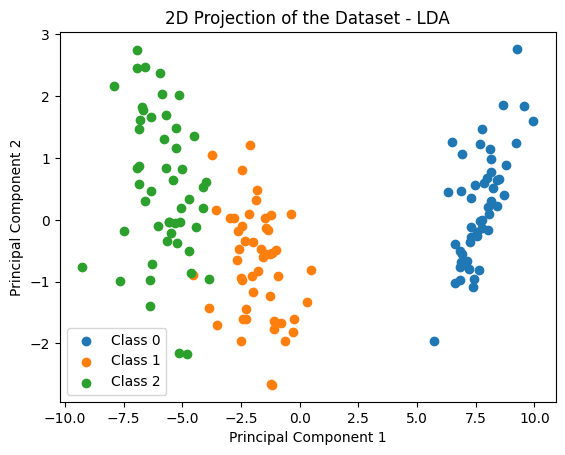

In [87]:
def plot_projected_dataset(Xp, y):
    """
    Plot the 2D projection of the dataset.

    Args:
        Xp (np.ndarray): The projected dataset of shape (2, n_samples).
        y (np.ndarray): The label vector of shape (n_samples,).
    """
    for label in np.unique(y):
        plt.scatter(Xp[0, y == label], Xp[1, y == label], label=f'Class {label}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('2D Projection of the Dataset - LDA')
    plt.legend()
    plt.show()

plot_projected_dataset(X_lda, y)

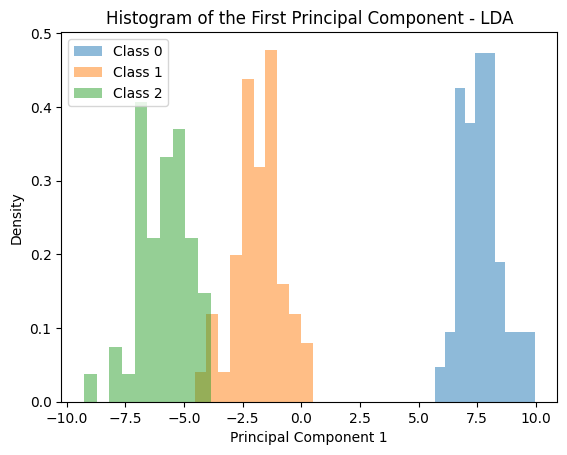

In [90]:
def plot_hist_first(Xp, y):
    """
    Plot the histogram of the first principal component.

    Args:
        Xp (np.ndarray): The projected dataset of shape (2, n_samples).
        y (np.ndarray): The label vector of shape (n_samples,).
    """
    plt.figure()
    for l in np.unique(y):
        plt.hist(Xp[0, y == l], label=f'Class {l}', alpha=0.5, bins=10, density=True)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Density')
    plt.title('Histogram of the First Principal Component - LDA')
    plt.legend()
    plt.show()

plot_hist_first(X_lda, y)